# SSVI surface diagnostics

Fit SSVI globally and Raw SVI independently by expiry on the screened 2025-08-29 SPX quotes. This notebook compares their fitted total-variance slices.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.raw_svi import fit_raw_svi_surface, raw_svi_total_variance
from src.ssvi import fit_ssvi_surface, ssvi_total_variance

PANEL_PATH = Path("../data/processed/spx_iv_panel_2025-08-29.csv")
panel = pd.read_csv(PANEL_PATH, parse_dates=["quote_date", "expiry_date"])
result = fit_ssvi_surface(panel)
raw_result = fit_raw_svi_surface(panel)
observations = result["observations"]
raw_observations = raw_result["observations"]

display(pd.Series({key: result[key] for key in ["rho", "eta", "gamma", "rmse"]}))
display(result["theta_by_expiry"])
display(raw_result["parameters_by_expiry"])


rho     -0.382447
eta      1.410054
gamma    0.580221
rmse     0.003747
dtype: float64

,quote_date,expiry_date,time_to_expiry,theta_atm
0,2025-08-29,2025-09-02,0.010959,0.000039
1,2025-08-29,2025-09-03,0.013699,0.000069
2,2025-08-29,2025-09-04,0.016438,0.000109
3,2025-08-29,2025-09-05,0.019178,0.000210
4,2025-08-29,2025-09-08,0.027397,0.000259
5,2025-08-29,2025-09-09,0.030137,0.000310
6,2025-08-29,2025-09-10,0.032877,0.000354
7,2025-08-29,2025-09-11,0.035616,0.000429
8,2025-08-29,2025-09-12,0.038356,0.000474
9,2025-08-29,2025-09-15,0.046575,0.000528


,quote_date,expiry_date,a,b,rho,m,sigma,rmse
0,2025-08-29,2025-09-02,-0.000060,0.008393,-0.938321,-0.027347,0.025505,0.000005
1,2025-08-29,2025-09-03,-0.000379,0.013950,-0.790007,-0.036569,0.048826,0.000006
2,2025-08-29,2025-09-04,-0.000682,0.017328,-0.749342,-0.043255,0.064835,0.000012
3,2025-08-29,2025-09-05,-0.001865,0.024203,-0.638365,-0.055407,0.106942,0.000024
4,2025-08-29,2025-09-08,-0.000760,0.020532,-0.877855,-0.063349,0.083448,0.000018
5,2025-08-29,2025-09-09,-0.001809,0.026512,-0.752549,-0.066540,0.111066,0.000025
6,2025-08-29,2025-09-10,-0.004400,0.035038,-0.538705,-0.055338,0.155469,0.000031
7,2025-08-29,2025-09-11,-0.001687,0.028520,-0.825318,-0.070605,0.112360,0.000017
8,2025-08-29,2025-09-12,-0.002354,0.031128,-0.733394,-0.062942,0.122087,0.000025
9,2025-08-29,2025-09-15,-0.004850,0.038593,-0.571728,-0.053266,0.161386,0.000033


## Representative expiries

For each target DTE, select the closest available expiry. Compare the shared-parameter SSVI fit with a separate five-parameter Raw SVI fit for that expiry. Both are fitted to the same screened OTM midpoint total-variance observations. Some Raw SVI fits reach parameter bounds, so treat their low in-sample errors and parameters cautiously.

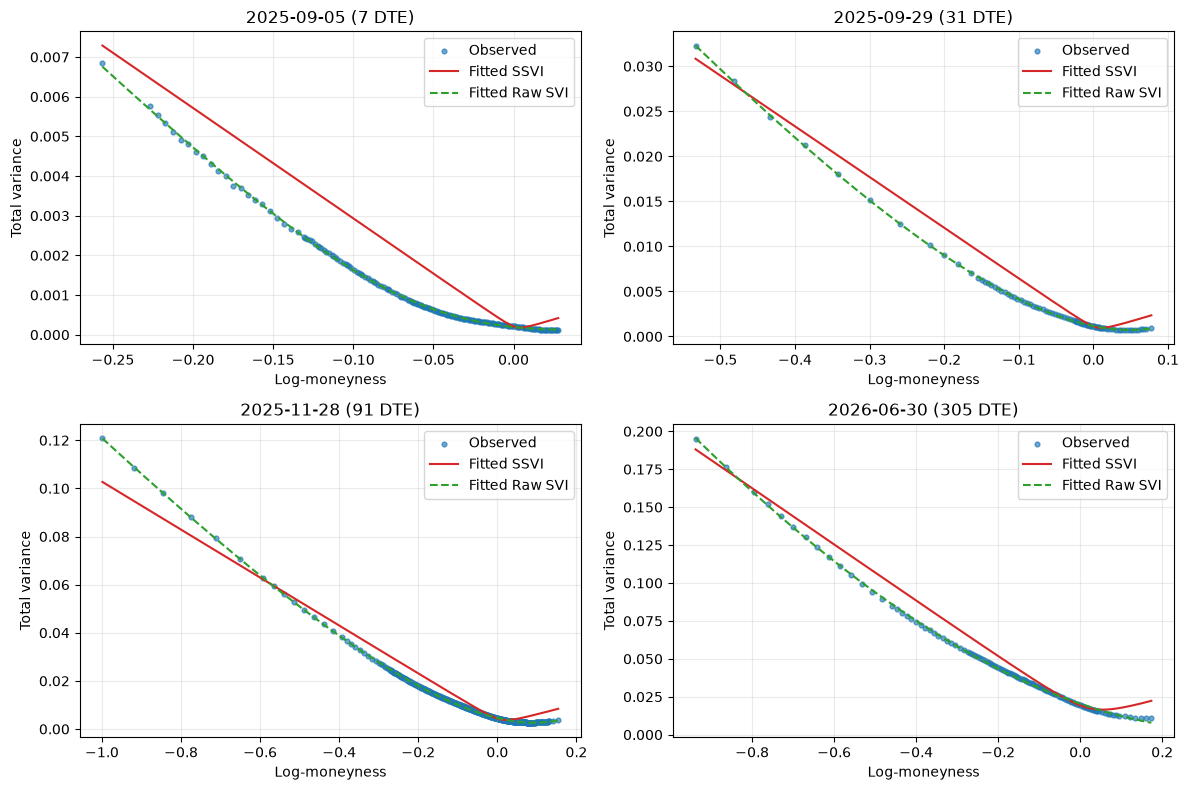

In [2]:
expiry_table = observations[["expiry_date", "days_to_expiry"]].drop_duplicates()
targets = [7, 30, 90, 300]
selected_expiries = []
for target in targets:
    nearest = expiry_table.iloc[(expiry_table["days_to_expiry"] - target).abs().argmin()]
    if nearest["expiry_date"] not in selected_expiries:
        selected_expiries.append(nearest["expiry_date"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, expiry in zip(axes.flat, selected_expiries):
    sample = observations.loc[observations["expiry_date"].eq(expiry)]
    k_grid = np.linspace(sample["log_moneyness"].min(), sample["log_moneyness"].max(), 300)
    theta = sample["theta_atm"].iloc[0]
    ax.scatter(sample["log_moneyness"], sample["market_w"], s=12, alpha=0.65, label="Observed")
    ax.plot(
        k_grid,
        ssvi_total_variance(k_grid, theta, result["rho"], result["eta"], result["gamma"]),
        color="tab:red", label="Fitted SSVI",
    )
    raw_parameters = raw_result["parameters_by_expiry"].loc[
        raw_result["parameters_by_expiry"]["expiry_date"].eq(expiry)
    ].iloc[0]
    raw_params = [raw_parameters[name] for name in ["a", "b", "rho", "m", "sigma"]]
    ax.plot(
        k_grid, raw_svi_total_variance(k_grid, *raw_params),
        color="tab:green", linestyle="--", label="Fitted Raw SVI",
    )
    ax.set(title=f"{expiry.date()} ({sample['days_to_expiry'].iloc[0]} DTE)", xlabel="Log-moneyness", ylabel="Total variance")
    ax.legend()
    ax.grid(alpha=0.25)
for ax in axes.flat[len(selected_expiries):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## Residuals

The residual is fitted minus observed total variance. Inspect whether errors change systematically with log-moneyness or maturity.

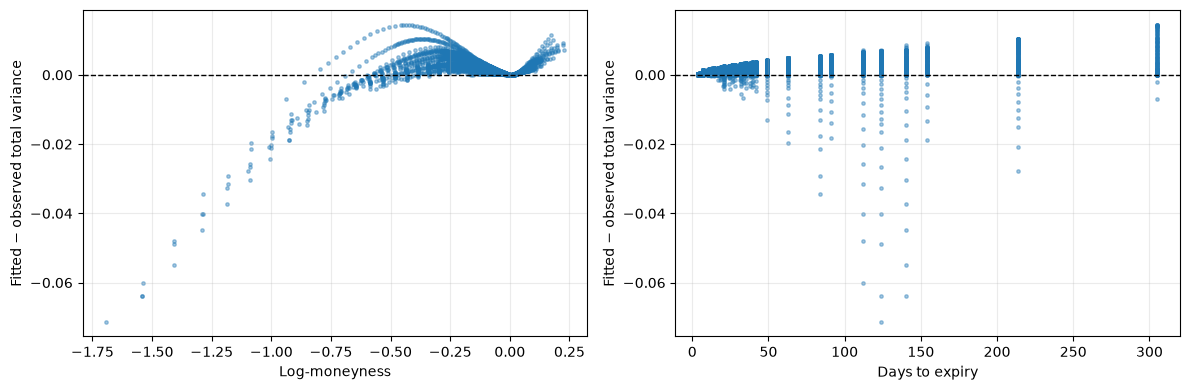

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(observations["log_moneyness"], observations["residual_w"], s=6, alpha=0.4)
axes[1].scatter(observations["days_to_expiry"], observations["residual_w"], s=6, alpha=0.4)
for ax, xlabel in zip(axes, ["Log-moneyness", "Days to expiry"]):
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set(xlabel=xlabel, ylabel="Fitted − observed total variance")
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Observed and fitted IV in 3D

The left plot shows the filtered observed IVs. The right plot shows fitted SSVI curves for every expiry, each over the log-moneyness range of that expiry's quotes. The curves are separate expiry slices; no interpolation between expiries is fitted.

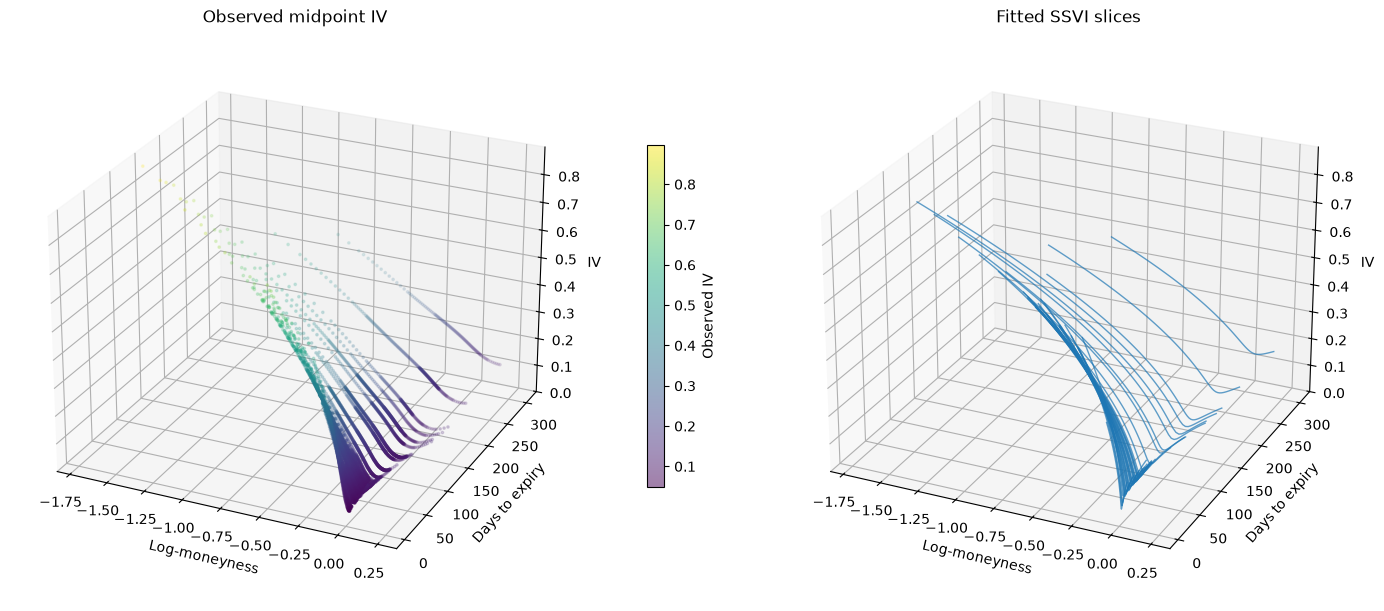

In [4]:
fig = plt.figure(figsize=(15, 6), layout="constrained")
observed_ax = fig.add_subplot(121, projection="3d")
fitted_ax = fig.add_subplot(122, projection="3d")

points = observed_ax.scatter(
    observations["log_moneyness"],
    observations["days_to_expiry"],
    observations["mid_iv"],
    c=observations["mid_iv"], s=3, alpha=0.5, cmap="viridis",
)
fig.colorbar(points, ax=observed_ax, shrink=0.6, pad=0.1, label="Observed IV")

for expiry, sample in observations.groupby("expiry_date"):
    k_grid = np.linspace(sample["log_moneyness"].min(), sample["log_moneyness"].max(), 100)
    theta = sample["theta_atm"].iloc[0]
    tau = sample["time_to_expiry"].iloc[0]
    fitted_iv = np.sqrt(
        ssvi_total_variance(k_grid, theta, result["rho"], result["eta"], result["gamma"]) / tau
    )
    fitted_ax.plot(
        k_grid, np.full_like(k_grid, sample["days_to_expiry"].iloc[0]), fitted_iv,
        color="tab:blue", linewidth=1, alpha=0.7,
    )

for ax, title in [(observed_ax, "Observed midpoint IV"), (fitted_ax, "Fitted SSVI slices")]:
    ax.set(xlabel="Log-moneyness", ylabel="Days to expiry", zlabel="IV", title=title)
    ax.set_zlim(0, observations["mid_iv"].max())
    ax.view_init(elev=25, azim=-65)
plt.show()

## Rendered SSVI surface

Drag the Plotly figure to rotate it and scroll to zoom. The mesh connects fitted expiry slices where adjacent expiries both have filtered quotes. Each row uses that expiry's estimated $\theta_{\mathrm{ATM}}$ and the shared $\rho$, $\eta$, and $\gamma$. The facets between rows are a plotting connection, not an estimated continuous ATM-variance curve.

In [5]:
expiry_ranges = observations.groupby("expiry_date").agg(
    days_to_expiry=("days_to_expiry", "first"),
    time_to_expiry=("time_to_expiry", "first"),
    theta_atm=("theta_atm", "first"),
    k_min=("log_moneyness", "min"),
    k_max=("log_moneyness", "max"),
).sort_values("days_to_expiry")

k_grid = np.linspace(observations["log_moneyness"].min(), observations["log_moneyness"].max(), 160)
k_mesh, dte_mesh = np.meshgrid(k_grid, expiry_ranges["days_to_expiry"])
theta = expiry_ranges["theta_atm"].to_numpy()[:, None]
tau = expiry_ranges["time_to_expiry"].to_numpy()[:, None]
iv_mesh = np.sqrt(
    ssvi_total_variance(k_mesh, theta, result["rho"], result["eta"], result["gamma"]) / tau
)
within_quotes = (
    (k_mesh >= expiry_ranges["k_min"].to_numpy()[:, None])
    & (k_mesh <= expiry_ranges["k_max"].to_numpy()[:, None])
)
iv_mesh = np.ma.masked_where(~within_quotes, iv_mesh)

import plotly.graph_objects as go

surface_fig = go.Figure(go.Surface(
    x=k_grid,
    y=expiry_ranges["days_to_expiry"].to_numpy(),
    z=iv_mesh.filled(np.nan),
    colorscale="Viridis",
    connectgaps=False,
    colorbar=dict(title="Fitted IV"),
    hovertemplate="k=%{x:.3f}<br>DTE=%{y}<br>IV=%{z:.3f}<extra></extra>",
))
surface_fig.update_layout(
    title="SSVI surface over quoted ranges",
    scene=dict(
        xaxis_title="Log-moneyness",
        yaxis_title="Days to expiry",
        zaxis_title="IV",
    ),
    width=900, height=650,
)
surface_fig.show()

## What changes without the quote screen?

This comparison uses every valid OTM midpoint IV (`use_for_surface`) from the existing panel, including zero-bid and wide-spread quotes. The panel's invalid or missing IVs still cannot be fitted. Each RMSE is calculated on its own sample, so compare the fitted parameters and shapes as well as the error.

,quotes,rho,eta,gamma,rmse
screened,6550.0,-0.382447,1.410054,0.580221,0.003747
unscreened,7426.0,-0.487200,0.714942,0.705938,0.005231


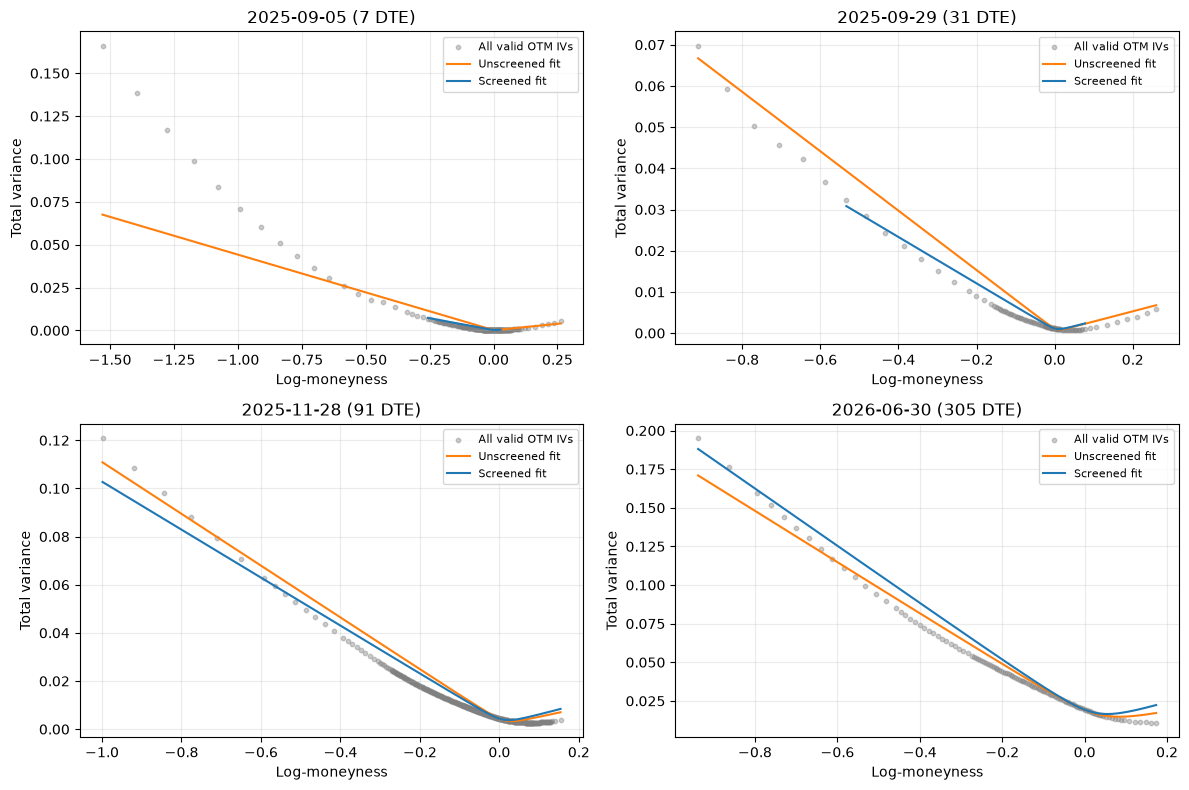

In [6]:
unscreened_result = fit_ssvi_surface(panel, apply_quote_screen=False)
unscreened_rows = unscreened_result["observations"]

comparison = pd.DataFrame({
    name: {
        "quotes": len(fit["observations"]),
        "rho": fit["rho"],
        "eta": fit["eta"],
        "gamma": fit["gamma"],
        "rmse": fit["rmse"],
    }
    for name, fit in [("screened", result), ("unscreened", unscreened_result)]
}).T
display(comparison)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, expiry in zip(axes.flat, selected_expiries):
    raw = unscreened_rows.loc[unscreened_rows["expiry_date"].eq(expiry)]
    clean = observations.loc[observations["expiry_date"].eq(expiry)]
    raw_k = np.linspace(raw["log_moneyness"].min(), raw["log_moneyness"].max(), 200)
    clean_k = np.linspace(clean["log_moneyness"].min(), clean["log_moneyness"].max(), 200)
    ax.scatter(raw["log_moneyness"], raw["market_w"], s=10, alpha=0.4, color="gray", label="All valid OTM IVs")
    ax.plot(raw_k, ssvi_total_variance(raw_k, raw["theta_atm"].iloc[0], unscreened_result["rho"], unscreened_result["eta"], unscreened_result["gamma"]), color="tab:orange", label="Unscreened fit")
    ax.plot(clean_k, ssvi_total_variance(clean_k, clean["theta_atm"].iloc[0], result["rho"], result["eta"], result["gamma"]), color="tab:blue", label="Screened fit")
    ax.set(title=f"{expiry.date()} ({raw['days_to_expiry'].iloc[0]} DTE)", xlabel="Log-moneyness", ylabel="Total variance")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
for ax in axes.flat[len(selected_expiries):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## Unscreened IVs and fitted surface

Drag to rotate. Black circles are observed midpoint IVs; black diamonds are SSVI values fitted at those exact quote locations. The coloured mesh connects the fitted expiry slices. All valid OTM observations enter the least-squares fit, but individual points need not lie on the surface. Hover over a circle to compare its observed and fitted IV.

In [7]:
raw_ranges = unscreened_rows.groupby("expiry_date").agg(
    days_to_expiry=("days_to_expiry", "first"),
    time_to_expiry=("time_to_expiry", "first"),
    theta_atm=("theta_atm", "first"),
    k_min=("log_moneyness", "min"),
    k_max=("log_moneyness", "max"),
).sort_values("days_to_expiry")
raw_k_grid = np.linspace(unscreened_rows["log_moneyness"].min(), unscreened_rows["log_moneyness"].max(), 160)
raw_k_mesh, raw_dte_mesh = np.meshgrid(raw_k_grid, raw_ranges["days_to_expiry"])
raw_iv_mesh = np.sqrt(
    ssvi_total_variance(
        raw_k_mesh, raw_ranges["theta_atm"].to_numpy()[:, None],
        unscreened_result["rho"], unscreened_result["eta"], unscreened_result["gamma"],
    ) / raw_ranges["time_to_expiry"].to_numpy()[:, None]
)
raw_coverage = (
    (raw_k_mesh >= raw_ranges["k_min"].to_numpy()[:, None])
    & (raw_k_mesh <= raw_ranges["k_max"].to_numpy()[:, None])
)
raw_iv_mesh = np.where(raw_coverage, raw_iv_mesh, np.nan)

iv_error = unscreened_rows["mid_iv"] - unscreened_rows["fitted_iv"]
display(pd.Series({
    "observations_fitted": len(unscreened_rows),
    "missing_fitted_iv": unscreened_rows["fitted_iv"].isna().sum(),
    "median_absolute_iv_error": iv_error.abs().median(),
    "maximum_absolute_iv_error": iv_error.abs().max(),
}))

unscreened_fig = go.Figure()
unscreened_fig.add_trace(go.Surface(
    x=raw_k_grid, y=raw_ranges["days_to_expiry"].to_numpy(), z=raw_iv_mesh,
    colorscale="Viridis", opacity=0.55, connectgaps=False,
    colorbar=dict(title="Fitted IV"), name="Unscreened SSVI",
))
unscreened_fig.add_trace(go.Scatter3d(
    x=unscreened_rows["log_moneyness"],
    y=unscreened_rows["days_to_expiry"],
    z=unscreened_rows["mid_iv"],
    mode="markers", marker=dict(size=1.5, color="black", opacity=0.35),
    customdata=np.column_stack((unscreened_rows["fitted_iv"], iv_error)),
    hovertemplate="k=%{x:.3f}<br>DTE=%{y}<br>Observed IV=%{z:.3f}<br>Fitted IV=%{customdata[0]:.3f}<br>Error=%{customdata[1]:+.3f}<extra></extra>",
    name="Observed IV at each quote",
))
unscreened_fig.add_trace(go.Scatter3d(
    x=unscreened_rows["log_moneyness"],
    y=unscreened_rows["days_to_expiry"],
    z=unscreened_rows["fitted_iv"],
    mode="markers", marker=dict(size=1.5, color="black", symbol="diamond", opacity=0.6),
    name="Fitted IV at each quote",
))
unscreened_fig.update_layout(
    title="SSVI fit without the quote screen",
    scene=dict(xaxis_title="Log-moneyness", yaxis_title="Days to expiry", zaxis_title="IV"),
    width=900, height=650,
)
unscreened_fig.show()

observations_fitted          7426.000000
missing_fitted_iv               0.000000
median_absolute_iv_error        0.045579
maximum_absolute_iv_error       1.066802
dtype: float64